# SeqOptPlot.convergence — optimization across generations\n\nA multi-panel view of the run converging: dominated **hypervolume** rising, front **spread** (diversity), and each objective's **best** front value per generation (`SeqOpt.history_`). Objectives can mix a model-on-features score with any external `fn(sequence)->float` predictor.

In [1]:
import numpy as np, pandas as pd
from sklearn.ensemble import RandomForestClassifier
import aaanalysis as aa
aa.options["verbose"] = False

df_seq = pd.DataFrame({"entry": ["P1"],
    "sequence": ["MKLAGTWYVFAILMVFWCGSTNQDEHKRPYLAGTWYVFAI"],
    "tmd_start": [11], "tmd_stop": [20]})
scales = list(aa.load_scales().columns[:4])
df_feat = pd.DataFrame({
    "feature": [f"TMD-Segment(1,1)-{s}" for s in scales],
    "category": ["Polarity","ASA/Volume","Polarity","Energy"],
    "subcategory": ["Hydrophobicity","Volume","Charge","Free energy"],
    "scale_name": scales, "abs_auc": [.30,.25,.20,.10], "abs_mean_dif": [.40,.30,.20,.10],
    "mean_dif": [.40,-.30,.20,-.10], "std_test": [.1]*4, "std_ref": [.1]*4,
    "feat_importance": [40.,30.,20.,10.]})
ref = pd.DataFrame({"entry": [f"R{i}" for i in range(8)],
    "sequence": ["MKLAGTWYVFAILMVFWCGSTNQDEHKRPYLAGTWYVFAI",
                 "ACDEFGHIKLMNPQRSTVWYACDEFGHIKLMNPQRSTVWY"] * 4,
    "tmd_start": [11]*8, "tmd_stop": [20]*8})
labels = [1,0]*4
sf = aa.SequenceFeature()
X = np.asarray(sf.feature_matrix(features=list(df_feat["feature"]),
                                 df_parts=sf.get_df_parts(df_seq=ref),
                                 df_scales=aa.load_scales()), float)
model = RandomForestClassifier(n_estimators=20, random_state=0).fit(X, labels)

# An EXTERNAL-PREDICTOR objective: any callable ``fn(sequence) -> float`` is optimized as an
# objective. Here a mock stand-in; in practice this could wrap a scikit/torch model or a
# sequence-level web tool / API (e.g. a topology or signal-peptide predictor like Phobius /
# TMHMM). Results are cached per distinct variant, so a slow API is queried once per variant.
def aromatic_run(sequence):
    import re
    runs = re.findall(r"[FWY]+", sequence)
    return float(max((len(r) for r in runs), default=0))

# Three objectives: maximize predicted activity, minimize the aromatic stretch (external
# predictor), minimize the number of mutations.
objectives = [("activity", "max", "delta_pred"),
              ("aromatic", "min", aromatic_run),
              ("parsimony", "min", "n_mut")]
seqopt = aa.SeqOpt(mode="importance", model=model, random_state=42)
df_pareto = seqopt.run(df_seq=df_seq, df_feat=df_feat, objectives=objectives,
                       pop_size=24, n_gen=15, n_mut_max=4, region="tmd")
aa.display_df(df_pareto, n_rows=10, show_shape=True)


/Users/stephanbreimann/Programming/1Packages/wt-seqopt-deap/aaanalysis/feature_engineering/_backend/cpp_run.py:163: UserWarning: CPP is using the Python kernel fallback — the compiled Cython extension is not available in this install. Output is bit-exact with the Cython path but ~2x slower. Reinstall via `pip install --force-reinstall aaanalysis` to fetch a prebuilt wheel.
  warnings.warn(


DataFrame shape: (1, 9)


,entry,variant,n_mut,sequence_mut,activity,aromatic,parsimony,rank,crowding
1,P1,,0,MKLAGTWYVFAILMV...HKRPYLAGTWYVFAI,0.000000,2.000000,0.000000,0,inf


Plot the per-generation convergence:

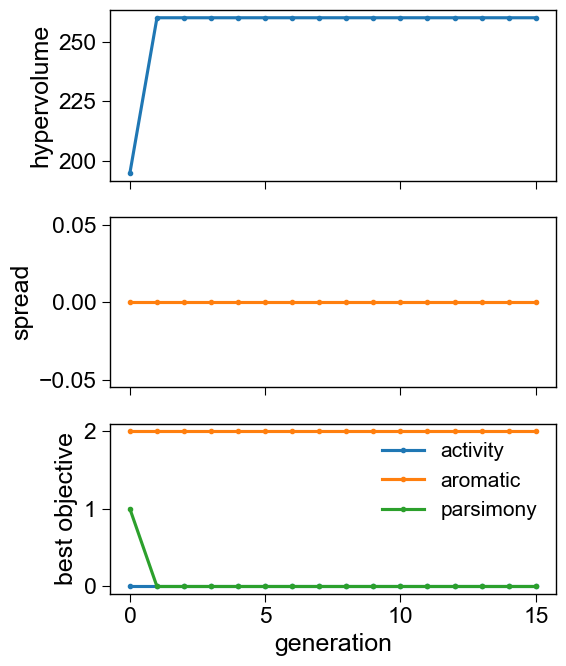

In [2]:
import matplotlib.pyplot as plt
aa.plot_settings()
aa.SeqOptPlot().convergence(history=seqopt.history_)
plt.tight_layout()
plt.show()